# Project 2 Brian Pruitt Spring 2026

### Task 1: Finding a .csv file and importing it into a DataFrame

In [3]:
import pandas as pd

df = pd.read_csv("StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


### Task 2: Computing Basic Statistics 

In [4]:
numeric_cols = ['math score', 'reading score']

overall_stats = df[numeric_cols].agg(['mean','max','min','std','median'])
overall_stats.loc['range'] = (df[numeric_cols].max() - df[numeric_cols].min())

overall_stats = overall_stats.round(2)
overall_stats

,math score,reading score
mean,66.09,69.17
max,100.00,100.00
min,0.00,17.00
std,15.16,14.60
median,66.00,70.00
range,100.00,83.00


#### Grouped

In [9]:
grouped_stats = df.groupby('gender')[numeric_cols].agg(['mean','max','min','std', 'median'])

grouped_stats['math score', 'range'] = (grouped_stats['math score', 'max'] -grouped_stats['math score', 'min'])

grouped_stats['reading score', 'range'] = (grouped_stats['reading score', 'max'] -grouped_stats['reading score', 'min'])

grouped_stats = grouped_stats.round(2)
grouped_stats

math score                        reading score                         \
             mean  max min    std median          mean  max min    std median   
gender                                                                          
female      63.63  100   0  15.49   65.0         72.61  100  17  14.38   73.0   
male        68.73  100  27  14.36   69.0         65.47  100  23  13.93   66.0   

       math score reading score  
            range         range  
gender                           
female        100            83  
male           73            77

### Task 3: Plotting some basic distributions

### Scatter plot

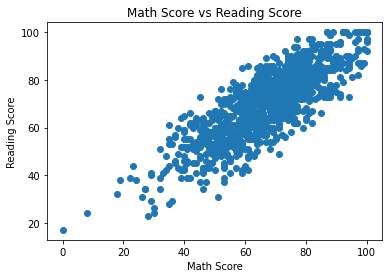

In [8]:
import matplotlib.pyplot as plt

plt.scatter(df['math score'], df['reading score'])
plt.xlabel("Math Score")
plt.ylabel("Reading Score")
plt.title("Math Score vs Reading Score")
plt.show()

### Histogram

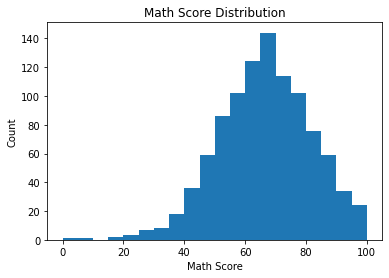

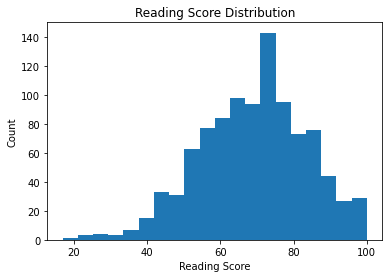

In [9]:
plt.hist(df['math score'], bins=20)
plt.title("Math Score Distribution")
plt.xlabel("Math Score")
plt.ylabel("Count")
plt.show()

plt.hist(df['reading score'], bins=20)
plt.title("Reading Score Distribution")
plt.xlabel("Reading Score")
plt.ylabel("Count")
plt.show()

### Histogram by category

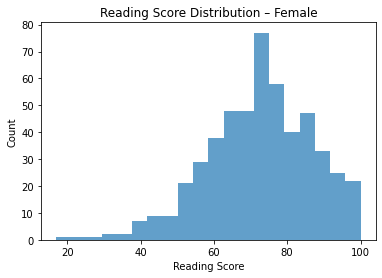

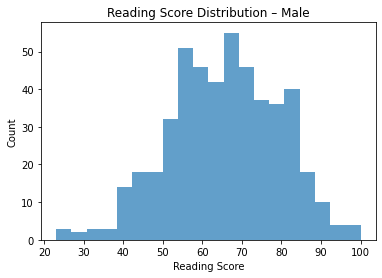

In [10]:
for gender in df['gender'].unique():
    subset = df[df['gender'] == gender]
    plt.hist(subset['reading score'], bins=20, alpha=0.7)
    plt.title(f"Reading Score Distribution – {gender.title()}")
    plt.xlabel("Reading Score")
    plt.ylabel("Count")
    plt.show()

This dataset examines student academic performance in relation to demographic characteristics, with a focus on math and reading exam scores. Across the entire dataset, reading scores were consistently higher than math scores, and both subjects showed wide ranges and noticeable variability. The scatter plot revealed a strong positive relationship between math and reading performance, suggesting that students who succeed in one subject tend to perform well in the other.

When examining performance by gender, small but noticeable differences 
emerged. Female students demonstrated higher average reading scores, while male students had a slightly higher average math score. However, both genders showed wide score distributions and similar standard deviations, indicating that individual differences are more significant than group‑level differences. The histograms further supported these findings by showing overlapping distributions between genders.

A useful extension of this analysis would involve examining test preparation course participation or parental level of education to investigate how external factors influence academic success. Combining this dataset with something like that would give a deeper insight into academic trends.